## Análise de hábitos e de estudantes
Notebook criado para realizar análises e previsões de notas em exames escolares com base em **habitos** e **características** de estudantes
- Bibliotecas utilizadas: Pandas 🐼 e Seaborn 📊

## Bloco 1: Importação de Bibliotecas e Ingestão de Dados

import pandas as pd: Carrega a biblioteca principal de manipulação e análise de dados em Python. O as pd é o padrão de mercado para manter o código limpo.

import seaborn as sns: Importa a biblioteca de visualização de dados baseada no Matplotlib, utilizada para gerar gráficos estatísticos avançados de forma simplificada.

In [1]:
import pandas as pd 
import seaborn as sns 

- pd.read_csv(...): Função que lê um arquivo de texto delimitado (CSV) e o converte em um objeto estruturado bidimensional chamado DataFrame (linhas e colunas).

- r"..." (Raw String): O prefixo r avisa o interpretador do Python para tratar as barras invertidas (\) como caracteres literais de texto. Sem isso, o Python tentaria interpretar sequências como \d ou \a como comandos de escape especiais, quebrando a leitura do caminho do arquivo no Windows.

- df = ...: Aloca o DataFrame resultante na variável df.

In [2]:
df = pd.read_csv(r".\data\dataset_aula03_student_habits_performance (1).csv")

- df.head() Exibe por padrão as 5 primeiras linhas do DataFrame. É o primeiro teste visual para garantir que o delimitador do CSV funcionou corretamente e que as colunas foram mapeadas de forma alinhada.

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


- df.tail() Exibe as 5 últimas linhas do conjunto de dados. No seu output, revelou que o dataset vai até o índice 999, confirmando visualmente a existência de 1.000 registros na base.

In [4]:
df.tail()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


## Bloco 2: Auditoria Estrutural e Tratamento de Nulos

- Método de diagnóstico que varre o metadado do DataFrame. Ele retorna:

- A classe do objeto (DataFrame).

- O intervalo do índice (1000 entries, 0 to 999).

- O nome de cada coluna acompanhado do tipo de dado mapeado (Dtype), como int64 (inteiros), float64 (decimais) e object (strings/texto).

- O contador de valores não nulos (Non-Null Count). Foi aqui que o desenvolvedor percebeu que a coluna parental_education_level tinha apenas 909 non-null, acusando a falta de 91 registros.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

- df["parental_education_level"]: Isola a coluna específica como uma estrutura unidimensional (Series).

- .isna(): Varre cada linha dessa coluna e retorna uma série booleana: True se o valor for nulo/ausente (NaN) e False se houver dado.

- .sum(): Como o Python interpreta True como 1 e False como 0, somar o resultado consolida o número exato de registros faltantes. O retorno foi 91.

In [6]:
df["parental_education_level"].isna().sum()

np.int64(91)

Funciona de forma inversa ao comando anterior. O método .notnull() valida onde existem dados válidos (True para preenchidos). O retorno foi 909, confirmando a consistência dos metadados anteriores.

In [7]:
df["parental_education_level"].notnull().sum()

np.int64(909)

- .fillna("Desconhecido"): Localiza os 91 registros nulos (NaN) dentro da coluna e os substitui pela string "Desconhecido".

- df["parental_education_level"] = ...: Aplica a substituição de volta na coluna original, sobrescrevendo-a. É uma técnica de imputação categórica clássica para não perder linhas preciosas de análise.

In [8]:
df["parental_education_level"] = df ["parental_education_level"].fillna("Desconhecido")

## Bloco 3: Validação do Tratamento e Cardinalidade

Executado novamente como um teste de regressão pós-tratamento. O retorno 0 provou que a limpeza de nulos foi realizada com sucesso.

In [9]:
df["parental_education_level"].isna().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   object 
 12  internet_quality               1000 non-null   ob

Retorna um array com os valores únicos presentes na coluna, sem repetições. O resultado mostrou: ['Master', 'High School', 'Bachelor', 'Desconhecido'], provando que o token de fallback foi integrado ao domínio da variável.

In [11]:
df["parental_education_level"].unique()

array(['Master', 'High School', 'Bachelor', 'Desconhecido'], dtype=object)

nunique (Number of Unique): Retorna a contagem (cardinalidade) de elementos únicos da coluna. O retorno foi 4.

In [12]:
df["parental_education_level"].nunique()

4

## Bloco 4: Filtros, Correlação e Visualização Gráfica

Criação de uma lista padrão do Python contendo apenas as colunas com dados estritamente numéricos para podermos aplicar cálculos matemáticos.

In [13]:
colunas = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

df[colunas]: Filtra o DataFrame original, trazendo apenas as colunas numéricas especificadas na lista.

- .corr(): Calcula a matriz de correlação linear de Pearson entre todas as combinações de variáveis numéricas.

- sns.heatmap(...): Plota o gráfico de calor.

- annot=True: Força a exibição dos valores numéricos dos coeficientes dentro de cada quadrado.

- cmap="coolwarm": Define a paleta de cores (azul para correlações negativas, vermelho para positivas).

- fmt=".2f": Formata os valores numéricos com duas casas decimais.

- ; (ponto e vírgula no final): Oculta o retorno de string do objeto do matplotlib no Jupyter, exibindo apenas o gráfico limpo.

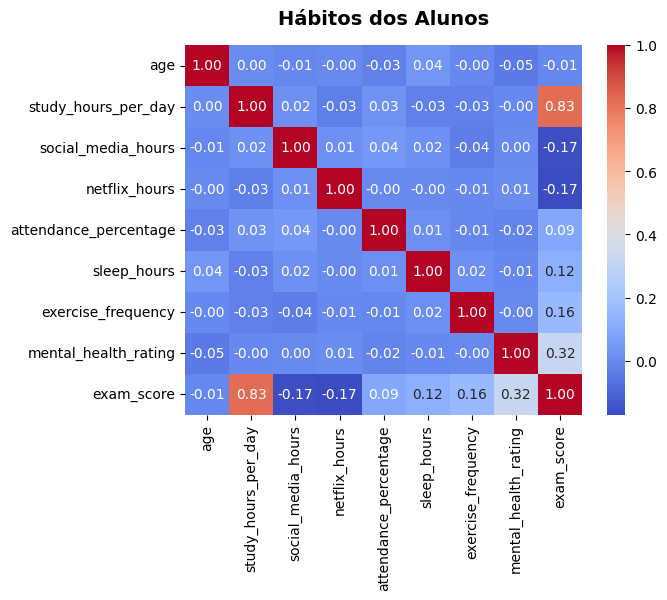

In [19]:

ax = sns.heatmap(data=df[colunas].corr(), annot=True, cmap="coolwarm", fmt=".2f")
ax.set_title("Hábitos dos Alunos", fontsize=14, pad=15, fontweight='bold');

- sns.lmplot: Gera um gráfico de dispersão (Scatter Plot) acoplado com uma linha de ajuste de regressão linear e uma sombra azul clara que representa o intervalo de confiança.

- x="..." e y="...": Define qual variável controlará o eixo horizontal e qual controlará o eixo vertical. Esse código provou graficamente o impacto massivo de horas estudadas sobre a nota final.

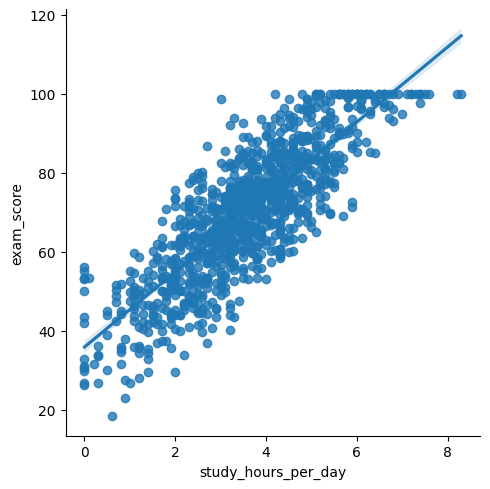

In [15]:
sns.lmplot(data=df,x="study_hours_per_day" , y= "exam_score");

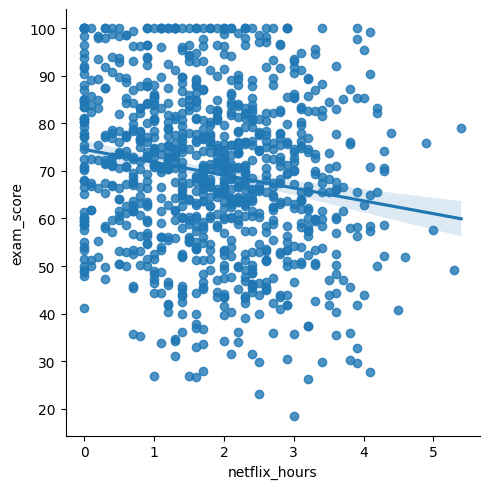

In [16]:
sns.lmplot(data=df,x="netflix_hours" , y="exam_score");

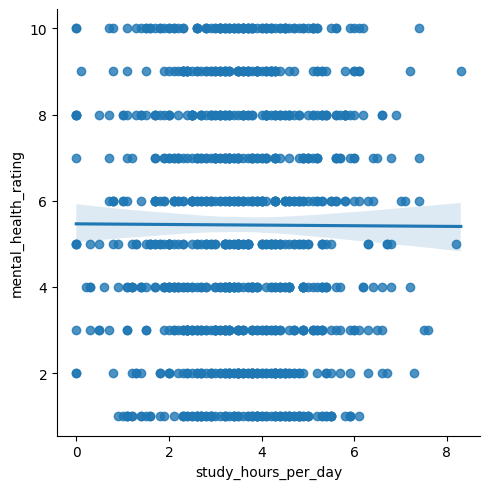

In [17]:
sns.lmplot(data=df,x="study_hours_per_day", y= "mental_health_rating");

## Bloco 5: Análise Amostral Matemática

- Criação de máscaras booleanas (vetores contendo apenas True ou False).

- filtro_horas_altas marca como True apenas os alunos que estudam 5 horas ou mais.

- filtro_horas_baixas marca como True quem estuda estritamente menos de 2 horas.

- df[filtro_horas_altas]: Aplica a máscara boolena. O Pandas filtra o DataFrame, mantendo apenas as linhas onde a condição era True.

- ["exam_score"]: Isola a coluna de notas desses alunos filtrados.

- .mean(): Calcula a média aritmética simples dessas notas, salvando os resultados em variáveis.

- f"..." (F-string): Formatação de strings que permite injetar variáveis diretamente dentro do texto usando chaves {}.

- :.2f: Modificador de formato que instrui o Python a arredondar e exibir a variável flutuante com exatamente duas casas decimais após o ponto, gerando as saídas limpas de 90.30 e 45.56 na tela.

In [18]:
filtro_horas_altas = df["study_hours_per_day"] >= 5
filtro_horas_baixas = df["study_hours_per_day"] < 2

media_alta = df[filtro_horas_altas]["exam_score"].mean()
media_baixa = df[filtro_horas_baixas]["exam_score"].mean()

print(f"A média das pessoas que estudaram 5 ou mais horas foi {media_alta:.2f}.")
print(f"Já a média, das pessoas que estudaram menos de duas horas, foi {media_baixa:.2f}.")

A média das pessoas que estudaram 5 ou mais horas foi 90.30.
Já a média, das pessoas que estudaram menos de duas horas, foi 45.56.
